# EDA & Feature Engineering cho Dự án Dự đoán Customer Churn

Notebook này thực hiện các bước đọc dữ liệu, khám phá dữ liệu (EDA), so sánh nhóm churn/không churn và chuẩn bị các đặc trưng quan trọng để hỗ trợ xây dựng mô hình dự đoán churn.

## 1. Import Required Libraries and Set Up Environment

- Import các thư viện cần thiết: pandas, numpy, matplotlib, seaborn, pyarrow.
- Thiết lập các tuỳ chọn hiển thị để xử lý dữ liệu lớn.
- Giải thích: Phần này chuẩn bị môi trường làm việc, đảm bảo có đủ thư viện để xử lý dữ liệu lớn và trực quan hóa.

In [1]:
# Import các thư viện cần thiết cho phân tích dữ liệu và trực quan hóa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import os

# Thiết lập các tuỳ chọn hiển thị để xử lý dữ liệu lớn
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set(style='whitegrid')

# Giải thích:
# - pandas, numpy: Xử lý và phân tích dữ liệu
# - matplotlib, seaborn: Trực quan hóa dữ liệu
# - pyarrow: Hỗ trợ đọc file parquet hiệu quả
# - Thiết lập hiển thị giúp dễ dàng quan sát dữ liệu lớn

## 2. Load Parquet Data Files

- Đọc các file parquet chính: transactions_master, causal_data, coupon_redempt, coupon, campaign, campaign_desc, customer_base_labeled, demographics.
- Sử dụng pandas.read_parquet với engine='pyarrow' để tối ưu hiệu năng.
- Giải thích: Đảm bảo dữ liệu được nạp đúng định dạng, kiểm tra sơ bộ số dòng/cột và dung lượng từng bảng.

In [2]:
# Định nghĩa đường dẫn các file dữ liệu
DATA_RAW = os.path.join('..', 'Data', 'Raw')
DATA_PROCESSED = os.path.join('..', 'Data', 'Processed')

# Đọc các file parquet (dùng os.path.join để tránh lỗi đường dẫn)
transactions_master = pd.read_parquet(os.path.join(DATA_PROCESSED, 'transactions_master.parquet'), engine='pyarrow')
causal_data = pd.read_parquet(os.path.join(DATA_RAW, 'causal_data.parquet'), engine='pyarrow')
coupon_redempt = pd.read_parquet(os.path.join(DATA_PROCESSED, 'coupon_redempt_clean.parquet'), engine='pyarrow')
coupon = pd.read_parquet(os.path.join(DATA_PROCESSED, 'coupon_clean.parquet'), engine='pyarrow')
campaign = pd.read_parquet(os.path.join(DATA_PROCESSED, 'campaign_table_clean.parquet'), engine='pyarrow')
campaign_desc = pd.read_parquet(os.path.join(DATA_PROCESSED, 'campaign_desc_clean.parquet'), engine='pyarrow')
customer_master = pd.read_parquet(os.path.join(DATA_PROCESSED, 'customer_base_labeled.parquet'), engine='pyarrow')
demography = pd.read_parquet(os.path.join(DATA_PROCESSED, 'demographics_imputed.parquet'), engine='pyarrow')
# Kiểm tra sơ bộ số dòng/cột và dung lượng từng bảng
def print_df_info(df, name):
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols, approx mem: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print_df_info(transactions_master, 'transactions_master')
print_df_info(causal_data, 'causal_data')
print_df_info(coupon_redempt, 'coupon_redempt')
print_df_info(campaign, 'campaign')
print_df_info(customer_master, 'customer_master')
print_df_info(demography, 'demography')

# Giải thích:
# - Dùng os.path.join để tránh lỗi escape sequence và đảm bảo tương thích đa hệ điều hành
# - Đọc thêm bảng campaign để hỗ trợ feature engineering

transactions_master: 2,548,770 rows x 15 cols, approx mem: 1024.00 MB
causal_data: 36,786,524 rows x 5 cols, approx mem: 3823.98 MB
coupon_redempt: 2,318 rows x 4 cols, approx mem: 0.26 MB
campaign: 7,208 rows x 3 cols, approx mem: 0.74 MB
customer_master: 2,500 rows x 16 cols, approx mem: 1.16 MB
demography: 801 rows x 8 cols, approx mem: 0.34 MB


In [3]:
from IPython.display import display
print("\nSample data from transactions_master:")
display(transactions_master.head())

print("\nSample data from causal_data:")
display(causal_data.head())

print("\nSample data from coupon_redempt:")
display(coupon_redempt.head())

print("\nSample data from coupon:")
display(coupon.head())

print("\nSample data from campaign:")
display(campaign.head())

print("\nSample data from customer_master:")
display(customer_master.head())

print("\nSample data from demography:")
display(demography.head())



Sample data from transactions_master:


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DEPARTMENT,BRAND,COMMODITY_DESC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.00,0.00,PRODUCE,Private,POTATOES
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.00,0.00,PRODUCE,National,ONIONS
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.00,0.00,PRODUCE,Private,VEGETABLES - ALL OTHERS
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.00,0.00,PRODUCE,National,TROPICAL FRUIT
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.00,0.00,PRODUCE,Private,ORGANICS FRUIT & VEGETABLES



Sample data from causal_data:


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A
3,26190,292,70,0,A
4,26190,293,70,0,A



Sample data from coupon_redempt:


...

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26



Sample data from customer_master:


,household_key,mean_IPT,std_IPT,last_purchase_day,personalized_threshold,recency,is_churn,Frequency,Monetary,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,8.51,4.58,706,17.67,5,0,83,4310.16,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,10,142.75,159.64,685,462.03,26,0,9,234.34,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,100,32.62,24.50,691,81.62,20,0,23,1959.22,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
3,1000,5.26,5.90,706,17.06,5,0,130,3972.44,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,1001,8.90,13.77,710,36.45,1,0,90,4074.02,45-54,U,50-74K,Homeowner,Unknown,1,None/Unknown



Sample data from demography:


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [4]:
causal_data.head()

,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A
3,26190,292,70,0,A
4,26190,293,70,0,A


## 3. Initial Data Exploration (EDA)

- Kiểm tra thông tin tổng quan từng bảng: info(), describe(), head().
- Kiểm tra missing values, kiểu dữ liệu, phân phối các biến chính.
- Giải thích: Giúp hiểu cấu trúc dữ liệu, phát hiện bất thường hoặc lỗi dữ liệu trước khi phân tích sâu.

### EDA bảng campaign
- Kiểm tra thông tin tổng quan, các trường dữ liệu, phân phối các loại campaign, thời gian diễn ra.
- Gợi ý các đặc trưng có thể tạo từ campaign: số lượng campaign từng khách hàng nhận, loại campaign phổ biến, thời gian gần nhất tham gia campaign, v.v.

In [5]:
# EDA bảng campaign
print("===== campaign =====")
display(campaign.head(3))
print(campaign.info())
print(campaign.describe(include='all'))
print("Missing values per column:")
print(campaign.isnull().sum())

# Phân phối các loại campaign
if 'CAMPAIGN_TYPE' in campaign.columns:
    print(campaign['CAMPAIGN_TYPE'].value_counts())

# Thời gian diễn ra campaign (nếu có trường ngày)
if 'START_DATE' in campaign.columns and 'END_DATE' in campaign.columns:
    print("Khoảng thời gian campaign:")
    print(campaign[['START_DATE', 'END_DATE']].agg(['min', 'max']))

# Gợi ý đặc trưng FE:
# - Số lượng campaign từng khách hàng nhận
# - Loại campaign phổ biến từng khách hàng
# - Thời gian gần nhất tham gia campaign
# (Có thể join với transactions hoặc customer_master để tạo đặc trưng này)

===== campaign =====


,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DESCRIPTION    7208 non-null   object
 1   household_key  7208 non-null   object
 2   CAMPAIGN       7208 non-null   int8  
dtypes: int8(1), object(2)
memory usage: 119.8+ KB
None
       DESCRIPTION household_key  CAMPAIGN
count         7208          7208   7208.00
unique           3          1584       NaN
top          TypeA          2317       NaN
freq          3979            17       NaN
mean           NaN           NaN     15.66
std            NaN           NaN      6.95
min            NaN           NaN      1.00
25%            NaN           NaN      9.00
50%            NaN           NaN     14.00
75%            NaN           NaN     20.00
max            NaN           NaN     30.00
Missing values per column:
DESCRIPTION      0
household_key    0
CAMPAIGN         0
dtype: int64


## 4. Compare Churn vs Non-Churn Groups

- Gộp nhãn churn vào customer_master hoặc transactions_master.
- So sánh các thông số cơ bản (số lượng giao dịch, tổng giá trị mua, tần suất mua, v.v.) giữa nhóm churn và không churn.
- Sử dụng groupby, agg và visualize bằng boxplot/histogram.
- Giải thích: Phát hiện sự khác biệt giữa hai nhóm, hỗ trợ ý tưởng xây dựng đặc trưng dự báo.

Frequency                                               Monetary  \
             count   mean    std  min   25%   50%    75%     max    count   
is_churn                                                                    
0          2198.00 101.80 105.53 2.00 38.00 74.00 129.75 1223.00  2198.00   
1           302.00  90.63  98.59 1.00 28.00 63.50 121.50  821.00   302.00   

                                                                
            mean     std   min    25%     50%     75%      max  
is_churn                                                        
0        3038.49 3025.33 28.96 960.31 2083.46 4090.03 26285.33  
1        2366.43 2460.74  8.17 583.99 1733.59 3286.03 18828.12

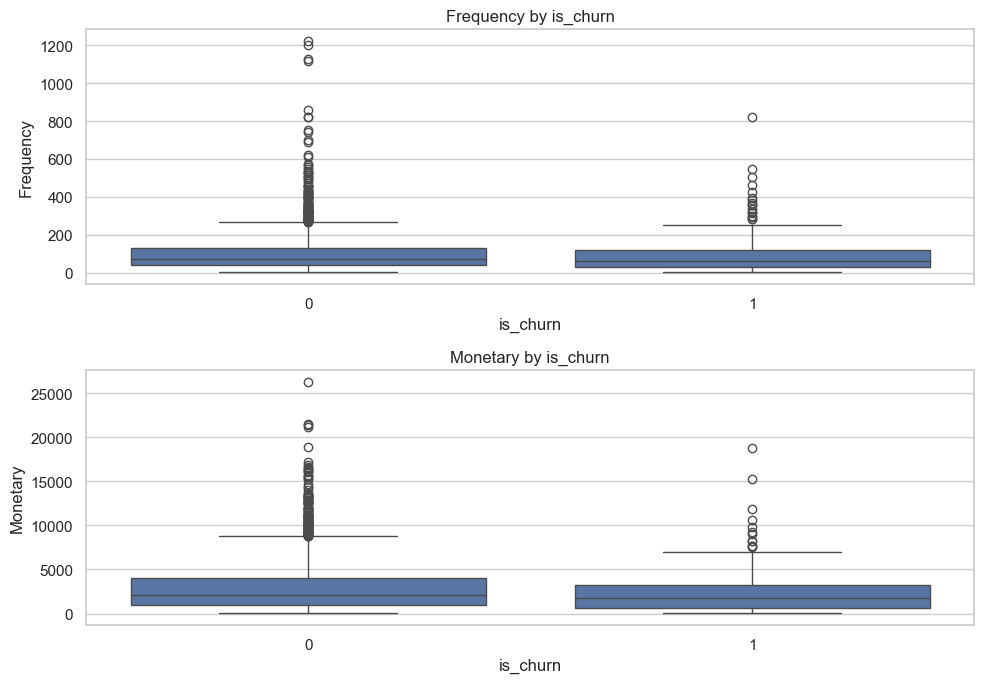

In [6]:
# Doc customer_base_labeled da co nhan churn (is_churn) va cac chi so san co
customer_base_labeled = pd.read_parquet(os.path.join(DATA_PROCESSED, 'customer_base_labeled.parquet'), engine='pyarrow')

# Chi EDA cac bien san co va bien da tao them (loai recency de tranh leak nhan)
cols_compare = ['Frequency', 'Monetary', 'Discount_Affinity', 'Discount_Affinity_clip']
cols_compare = [col for col in cols_compare if col in customer_base_labeled.columns]
if len(cols_compare) == 0:
    print('Khong co bien hop le de so sanh.')
else:
    churn_stats = customer_base_labeled.groupby('is_churn')[cols_compare].describe()
    display(churn_stats)

    # Boxplot so sanh giua 2 nhom churn/khong churn
    n_rows = len(cols_compare)
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 3.5 * n_rows))
    if n_rows == 1:
        axes = [axes]
    for i, col in enumerate(cols_compare):
        sns.boxplot(x='is_churn', y=col, data=customer_base_labeled, ax=axes[i])
        axes[i].set_title(f'{col} by is_churn')
    plt.tight_layout()
    plt.show()

# Giai thich:
# - Chi dung cac bien san co (frequency, monetary) va bien da tao (Discount_Affinity, Discount_Affinity_clip)
# - Loai recency de tranh leak nhan
# - Uu tien boxplot de so sanh hai nhom

## 5. Aggregate Causal Data by Week

- Do causal_data rất lớn, chỉ thực hiện aggregate theo tuần và product_id (không join trực tiếp vào bảng khách hàng).
- Tính toán số lượng/mức độ xuất hiện display, mailer theo tuần.
- Giải thích: Chuẩn bị dữ liệu causal để sau này tạo đặc trưng tổng hợp theo tuần, giảm tải bộ nhớ và tăng hiệu quả xử lý.

In [7]:
# Aggregate causal_data theo tuần và product_id
causal_weekly = causal_data.groupby(['WEEK_NO', 'PRODUCT_ID']).agg({
    'display': 'nunique',
    'mailer': 'nunique'
}).reset_index()
causal_weekly.rename(columns={'display': 'Num_Display_Types', 'mailer': 'Num_Mailer_Types'}, inplace=True)
display(causal_weekly.head())

# Giải thích:
# - Gom nhóm theo tuần và sản phẩm để giảm kích thước dữ liệu
# - Đếm số loại display/mailer giúp tạo đặc trưng tổng hợp cho các phân tích tiếp theo

,WEEK_NO,PRODUCT_ID,Num_Display_Types,Num_Mailer_Types
0,9,26540,1,1
1,9,26601,3,1
2,9,26636,2,1
3,9,26691,7,1
4,9,26738,3,1


In [8]:
# --- CELL MỚI 1: XỬ LÝ DEMOGRAPHICS ---

# Tạo danh sách các khách hàng có trong transactions
all_customers = pd.DataFrame({'household_key': transactions_master['household_key'].unique()})

# Merge với demography đã load từ trước
demography_full = pd.merge(all_customers, demography, on='household_key', how='left')

# Tạo feature nhị phân: 1 nếu có thông tin (AGE_DESC không bị null), 0 nếu không có
demography_full['has_demographic_info'] = np.where(demography_full['AGE_DESC'].notna(), 1, 0)

# Điền chuỗi "Unknown" cho toàn bộ giá trị NaN
demography_full.fillna('Unknown', inplace=True)

print("Demographics processed. Sample:")
display(demography_full[['household_key', 'AGE_DESC', 'INCOME_DESC', 'has_demographic_info']].head())

Demographics processed. Sample:


,household_key,AGE_DESC,INCOME_DESC,has_demographic_info
0,2375,Unknown,Unknown,0
1,1364,65+,100-124K,1
2,1130,55-64,25-34K,1
3,1173,Unknown,Unknown,0
4,98,35-44,35-49K,1


In [9]:
import numpy as np
import pandas as pd

# 1. THIẾT LẬP CUT-OFF DATE (Cắt đứt rò rỉ dữ liệu)
# Lấy mốc 711 lùi lại 60 ngày làm thời điểm chốt sổ quan sát
cut_off_day = 711 - 60 

# Chỉ lấy các giao dịch xảy ra TRƯỚC hoặc BẰNG cut_off_day
obs_txns = transactions_master[transactions_master['DAY'] <= cut_off_day]

# 2. TÍNH CÁC FEATURES CƠ BẢN TRÊN TẬP QUAN SÁT
agg_funcs = {
    'BASKET_ID': 'nunique',           
    'SALES_VALUE': 'sum',             
    'COUPON_DISC': lambda x: np.sum(np.abs(x)), 
    'DAY': 'min'  # Chỉ lấy ngày mua đầu tiên
}

customer_features = obs_txns.groupby('household_key').agg(agg_funcs).reset_index()
customer_features.columns = ['household_key', 'Frequency', 'Monetary', 'Total_Coupon_Discount', 'first_purchase_day']

# 3. CUSTOMER LIFETIME (Không Rò Rỉ)
# Khoảng cách từ lúc mua lần đầu đến ngày chốt sổ (không phụ thuộc vào lúc họ rời đi)
customer_features['customer_lifetime'] = cut_off_day - customer_features['first_purchase_day']
customer_features['customer_lifetime'] = np.where(customer_features['customer_lifetime'] <= 0, 1, customer_features['customer_lifetime'])

# Các tỷ lệ cơ bản
customer_features['coupon_dependency'] = customer_features['Total_Coupon_Discount'] / (customer_features['Monetary'] + 1e-5)
customer_features['avg_transaction_value'] = customer_features['Monetary'] / customer_features['Frequency']
customer_features['session_frequency'] = customer_features['Frequency'] / customer_features['customer_lifetime']

# 4. ACTIVITY SLOPE TRÊN TẬP QUAN SÁT
# Động lượng 30 ngày sát cut-off vs 90 ngày trước đó
obs_txns['days_to_cutoff'] = cut_off_day - obs_txns['DAY']

freq_30d = obs_txns[obs_txns['days_to_cutoff'] <= 30].groupby('household_key')['BASKET_ID'].nunique().reset_index()
freq_30d.rename(columns={'BASKET_ID': 'Freq_Last_30_Days'}, inplace=True)

freq_90d_past = obs_txns[(obs_txns['days_to_cutoff'] > 30) & (obs_txns['days_to_cutoff'] <= 120)].groupby('household_key')['BASKET_ID'].nunique().reset_index()
freq_90d_past.rename(columns={'BASKET_ID': 'Freq_Past_90_Days'}, inplace=True)

customer_features = pd.merge(customer_features, freq_30d, on='household_key', how='left')
customer_features = pd.merge(customer_features, freq_90d_past, on='household_key', how='left')
customer_features['Freq_Last_30_Days'] = customer_features['Freq_Last_30_Days'].fillna(0)
customer_features['Freq_Past_90_Days'] = customer_features['Freq_Past_90_Days'].fillna(0)

customer_features['activity_slope'] = (customer_features['Freq_Last_30_Days'] / 30) / ((customer_features['Freq_Past_90_Days'] / 90) + 1e-5)

customer_features.drop(columns=['Total_Coupon_Discount', 'first_purchase_day', 'Freq_Last_30_Days', 'Freq_Past_90_Days'], inplace=True)

display(customer_features.head(10))

C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\2345563729.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_txns['days_to_cutoff'] = cut_off_day - obs_txns['DAY']


,household_key,Frequency,Monetary,customer_lifetime,coupon_dependency,avg_transaction_value,session_frequency,activity_slope
0,1,75,3849.70,600,0.02,51.33,0.12,1.00
1,10,7,163.94,537,0.00,23.42,0.01,0.00
2,100,21,1743.10,645,0.00,83.00,0.03,0.00
3,1000,120,3630.00,602,0.00,30.25,0.20,1.24
4,1001,72,3376.39,635,0.00,46.89,0.11,0.55
5,1002,28,895.45,578,0.00,31.98,0.05,4.50
6,1003,62,2542.17,623,0.00,41.00,0.10,0.00
7,1004,197,2441.93,568,0.00,12.40,0.35,0.81
8,1005,164,2202.45,536,0.00,13.43,0.31,0.49
9,1006,9,121.51,598,0.04,13.50,0.02,1.50


Mean values by Churn status:


,Frequency,Monetary,coupon_dependency,activity_slope,avg_time_between_purchases,customer_lifetime,avg_transaction_value,session_frequency
churn_flag,,,,,,,,
0,92.06,2718.85,0.00,127.15,17.73,584.56,32.34,0.16
1,88.19,2293.11,0.00,33.72,18.49,584.13,29.96,0.15


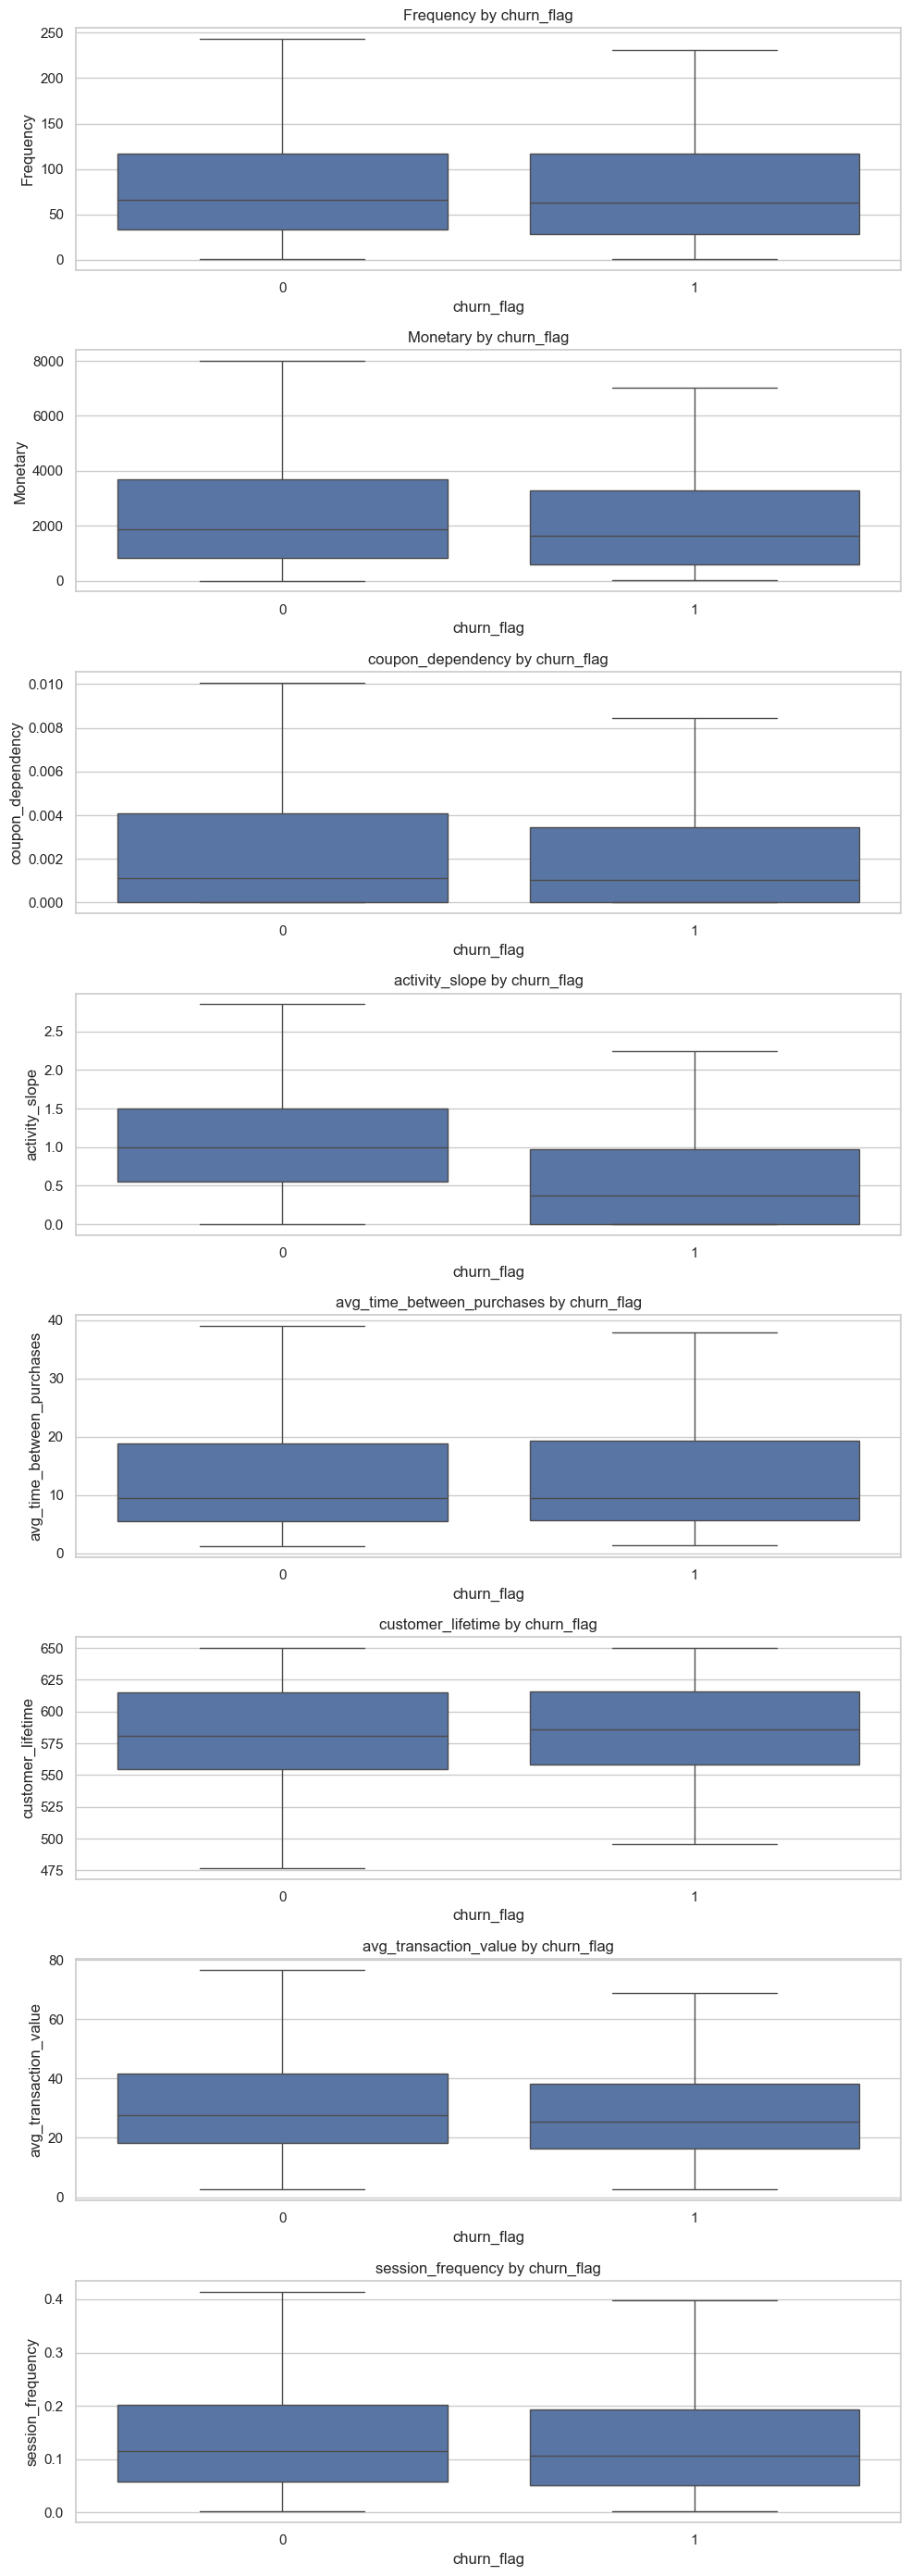

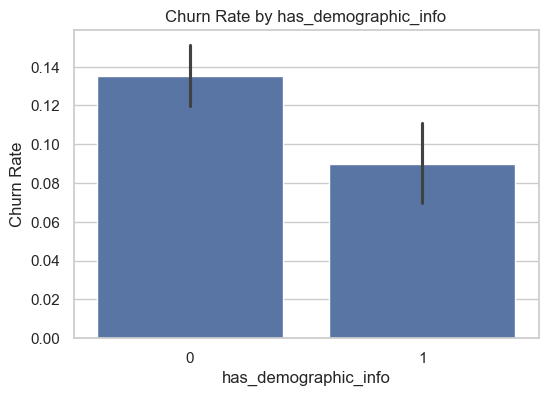

In [10]:
# --- CELL MỚI 3 (HOÀN THIỆN): MERGE DỮ LIỆU CUỐI CÙNG VÀ TRỰC QUAN HÓA EDA ---

# 1. Lấy nhãn 'is_churn' và 'mean_IPT' từ customer_master (Loại bỏ recency)
labels_and_ipt = customer_master[['household_key', 'is_churn', 'mean_IPT']].copy()

# Đổi tên biến mean_IPT và is_churn cho khớp với format bạn cần
labels_and_ipt.rename(columns={
    'is_churn': 'churn_flag',
    'mean_IPT': 'avg_time_between_purchases'
}, inplace=True)

# 2. Gộp các bảng tính năng lại (Sử dụng trực tiếp household_key)
df_final = pd.merge(labels_and_ipt, customer_features, on='household_key', how='inner')
df_final = pd.merge(df_final, demography_full[['household_key', 'has_demographic_info']], on='household_key', how='left')

# 3. Chốt danh sách cột (đã đổi customer_id thành household_key)
final_columns = [
    'household_key', 'Frequency', 'Monetary', 'has_demographic_info', 
    'coupon_dependency', 'activity_slope', 'avg_time_between_purchases', 
    'customer_lifetime', 'avg_transaction_value', 'session_frequency', 'churn_flag'
]
df_final = df_final[final_columns]

# ==========================================
# PHẦN EDA: ĐÁNH GIÁ FEATURE
# ==========================================

# Danh sách các biến liên tục cần so sánh bằng Boxplot
cols_to_compare = [
    'Frequency', 'Monetary', 'coupon_dependency', 'activity_slope', 
    'avg_time_between_purchases', 'customer_lifetime', 
    'avg_transaction_value', 'session_frequency'
]

# EDA: Thống kê mô tả
churn_stats = df_final.groupby('churn_flag')[cols_to_compare].mean()
print("Mean values by Churn status:")
display(churn_stats)

# EDA: Trực quan hóa bằng Boxplot
n_rows = len(cols_to_compare)
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 3.5 * n_rows))

# Tránh lỗi nếu chỉ có 1 row (dù trường hợp này > 1)
if n_rows == 1:
    axes = [axes]

for i, col in enumerate(cols_to_compare):
    # showfliers=False giúp ẩn đi các điểm outliers quá xa, giúp boxplot dễ nhìn hơn
    sns.boxplot(x='churn_flag', y=col, data=df_final, ax=axes[i], showfliers=False)
    axes[i].set_title(f'{col} by churn_flag')
    
plt.tight_layout()
plt.show()

# EDA riêng cho biến Categorical / Binary (has_demographic_info)
plt.figure(figsize=(6,4))
sns.barplot(x='has_demographic_info', y='churn_flag', data=df_final)
plt.title('Churn Rate by has_demographic_info')
plt.ylabel('Churn Rate')
plt.show()

In [11]:
pip install imblearn.over_sampling

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement imblearn.over_sampling (from versions: none)
ERROR: No matching distribution found for imblearn.over_sampling


In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# ==============================================================================
# BƯỚC 1: LOAD DỮ LIỆU & THIẾT LẬP CUT-OFF (CHỐNG LEAKAGE)
# ==============================================================================
DATA_PROCESSED = '../Data/Processed/'
DATA_RAW = '../Data/Raw/'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Đọc dữ liệu lõi
transactions_master = pd.read_parquet(os.path.join(DATA_PROCESSED, 'transactions_master.parquet'))
customer_master = pd.read_parquet(os.path.join(DATA_PROCESSED, 'customer_base_labeled.parquet'))

# 2. Đọc các bảng vệ tinh (Product, Causal, Campaign, Coupon)
product = pd.read_parquet(os.path.join(DATA_RAW, 'product.parquet'))
causal_data = pd.read_parquet(os.path.join(DATA_RAW, 'causal_data.parquet'))
campaign_table = pd.read_parquet(os.path.join(DATA_PROCESSED, 'campaign_table_clean.parquet'))
coupon = pd.read_parquet(os.path.join(DATA_PROCESSED, 'coupon_clean.parquet'))

# 3. THIẾT LẬP CUT-OFF (Mô phỏng thực tế: Dừng dữ liệu 60 ngày trước ngày hiện tại để train)
CUT_OFF_DAY = 711 - 60 
print(f"Cut-off Date: Day {CUT_OFF_DAY}")

# Lọc các giao dịch TRƯỚC VÀ BẰNG Cut-off Date
obs_txns = transactions_master[transactions_master['DAY'] <= CUT_OFF_DAY].copy()

# Khởi tạo bảng Final với Customer ID và Nhãn Churn (và mean_IPT nếu cần)
df_final = customer_master[['household_key', 'is_churn', 'mean_IPT']].copy()
df_final.rename(columns={'is_churn': 'churn_flag', 'mean_IPT': 'avg_time_between_purchases'}, inplace=True)

Cut-off Date: Day 651


In [13]:
# ==============================================================================
# BƯỚC 2: TÍNH CÁC FEATURES CƠ BẢN (TRÊN TẬP QUAN SÁT obs_txns)
# ==============================================================================
print("Đang tạo các đặc trưng cơ bản (RFM, Slopes, Affinities)...")

# 1. Tính RFM và Lifetime
agg_funcs = {
    'BASKET_ID': 'nunique',           
    'SALES_VALUE': 'sum',             
    'COUPON_DISC': lambda x: np.sum(np.abs(x)), 
    'DAY': 'min'  
}
customer_features = obs_txns.groupby('household_key').agg(agg_funcs).reset_index()
customer_features.columns = ['household_key', 'Frequency', 'Monetary', 'Total_Coupon_Discount', 'first_purchase_day']

# Customer Lifetime
customer_features['customer_lifetime'] = CUT_OFF_DAY - customer_features['first_purchase_day']
customer_features['customer_lifetime'] = np.where(customer_features['customer_lifetime'] <= 0, 1, customer_features['customer_lifetime'])

# Ratios
customer_features['coupon_dependency'] = customer_features['Total_Coupon_Discount'] / (customer_features['Monetary'] + 1e-5)
customer_features['avg_transaction_value'] = customer_features['Monetary'] / customer_features['Frequency']
customer_features['session_frequency'] = customer_features['Frequency'] / customer_features['customer_lifetime']

# 2. Tính Activity Slope
obs_txns['days_to_cutoff'] = CUT_OFF_DAY - obs_txns['DAY']

freq_30d = obs_txns[obs_txns['days_to_cutoff'] <= 30].groupby('household_key')['BASKET_ID'].nunique().reset_index(name='Freq_30D')
freq_90d_past = obs_txns[(obs_txns['days_to_cutoff'] > 30) & (obs_txns['days_to_cutoff'] <= 120)].groupby('household_key')['BASKET_ID'].nunique().reset_index(name='Freq_90D_Past')

customer_features = pd.merge(customer_features, freq_30d, on='household_key', how='left').fillna(0)
customer_features = pd.merge(customer_features, freq_90d_past, on='household_key', how='left').fillna(0)
customer_features['activity_slope'] = (customer_features['Freq_30D'] / 30) / ((customer_features['Freq_90D_Past'] / 90) + 1e-5)

# Xóa cột tạm
customer_features.drop(columns=['Total_Coupon_Discount', 'first_purchase_day', 'Freq_30D', 'Freq_90D_Past'], inplace=True)
df_final = pd.merge(df_final, customer_features, on='household_key', how='left')

# 3. Tính Brand Private Ratio
if 'BRAND' not in obs_txns.columns: # Kiểm tra xem lúc M1 làm sạch có merge BRAND chưa
    obs_txns = pd.merge(obs_txns, product[['PRODUCT_ID', 'BRAND']], on='PRODUCT_ID', how='left')

brand_qty = obs_txns.groupby(['household_key', 'BRAND'])['QUANTITY'].sum().unstack(fill_value=0).reset_index()
brand_qty['Private_Brand_Ratio'] = brand_qty.get('Private', 0) / (brand_qty.get('Private', 0) + brand_qty.get('National', 0) + 1e-5)
df_final = pd.merge(df_final, brand_qty[['household_key', 'Private_Brand_Ratio']], on='household_key', how='left')

Đang tạo các đặc trưng cơ bản (RFM, Slopes, Affinities)...


In [14]:
# ==============================================================================
# BƯỚC 3: TẠO FEATURES TỪ CAUSAL VÀ CAMPAIGN
# ==============================================================================
print("Đang xử lý dữ liệu Marketing (Causal & Campaign)...")

# 1. Causal Data (Đếm xem trong giỏ hàng có bao nhiêu món bị ảnh hưởng bởi Display/Mailer)
# Ép kiểu để merge an toàn
causal_data['PRODUCT_ID'] = causal_data['PRODUCT_ID'].astype(str)
causal_data['WEEK_NO'] = causal_data['WEEK_NO'].astype(int)
obs_txns['PRODUCT_ID'] = obs_txns['PRODUCT_ID'].astype(str)
obs_txns['WEEK_NO'] = obs_txns['WEEK_NO'].astype(int)

# Tối ưu Causal: Nếu sản phẩm có Display/Mailer ở BẤT KỲ cửa hàng nào trong tuần đó thì đánh dấu là 1
causal_data['is_display'] = np.where(~causal_data['display'].isin(['0', ' ', 'None', 'NaN']), 1, 0)
causal_data['is_mailer'] = np.where(~causal_data['mailer'].isin(['0', ' ', 'None', 'NaN']), 1, 0)
causal_agg = causal_data.groupby(['WEEK_NO', 'PRODUCT_ID']).agg({'is_display': 'max', 'is_mailer': 'max'}).reset_index()

# Merge Causal với Transactions
txn_causal = pd.merge(obs_txns[['household_key', 'WEEK_NO', 'PRODUCT_ID', 'QUANTITY']], causal_agg, on=['WEEK_NO', 'PRODUCT_ID'], how='left').fillna(0)

# Tính % hàng hóa khách mua bị ảnh hưởng bởi khuyến mãi điểm bán
causal_features = txn_causal.groupby('household_key').agg(
    Total_Qty=('QUANTITY', 'sum'),
    Qty_Display=('is_display', lambda x: np.sum(x * txn_causal.loc[x.index, 'QUANTITY'])),
    Qty_Mailer=('is_mailer', lambda x: np.sum(x * txn_causal.loc[x.index, 'QUANTITY']))
).reset_index()

causal_features['Display_Responsiveness'] = causal_features['Qty_Display'] / (causal_features['Total_Qty'] + 1e-5)
causal_features['Mailer_Responsiveness'] = causal_features['Qty_Mailer'] / (causal_features['Total_Qty'] + 1e-5)

df_final = pd.merge(df_final, causal_features[['household_key', 'Display_Responsiveness', 'Mailer_Responsiveness']], on='household_key', how='left')

# 2. Campaign Data
# Số lượng Campaign khách hàng được nhắm tới
campaign_table['household_key'] = campaign_table['household_key'].astype(str)
df_final['household_key'] = df_final['household_key'].astype(str)
campaign_counts = campaign_table.groupby('household_key').size().reset_index(name='Campaigns_Received')

df_final = pd.merge(df_final, campaign_counts, on='household_key', how='left')
df_final['Campaigns_Received'].fillna(0, inplace=True)
df_final.fillna(0, inplace=True) # Fillna lần cuối cho toàn bộ

print(f"Kích thước Dữ liệu cuối cùng: {df_final.shape}")

Đang xử lý dữ liệu Marketing (Causal & Campaign)...
Kích thước Dữ liệu cuối cùng: (2500, 14)


C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\2466480297.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Campaigns_Received'].fillna(0, inplace=True)


In [ ]:
# ==============================================================================
# BƯỚC 3 (BỔ SUNG CẬP NHẬT): TẠO FEATURES MARKETING TỪ CAMPAIGN
# ==============================================================================
print("Đang tạo đặc trưng nâng cao từ bảng Campaign...")

# 1. Merge bảng campaign_table và campaign_desc để lấy ngày và loại chiến dịch
try:
    campaign_desc = pd.read_parquet(os.path.join(DATA_PROCESSED, 'campaign_desc_clean.parquet'))
    camp_full = pd.merge(campaign_table, campaign_desc, on='CAMPAIGN', how='left')
    
    # 2. CHỐNG LEAK DATA: Chỉ lấy các campaign BẮT ĐẦU trước ngày chốt sổ
    camp_obs = camp_full[camp_full['START_DAY'] <= CUT_OFF_DAY].copy()
    camp_obs['household_key'] = camp_obs['household_key'].astype(str)

    # 3. Tạo biến: Số lượng campaign nhận được & Loại Campaign (Type A, B, C)
    # Ưu tiên cột DESCRIPTION, nếu không có thì fallback sang CAMPAIGN_TYPE hoặc CAMPAIGN
    if 'DESCRIPTION' in camp_obs.columns:
        type_col = 'DESCRIPTION'
    elif 'CAMPAIGN_TYPE' in camp_obs.columns:
        type_col = 'CAMPAIGN_TYPE'
    else:
        type_col = 'CAMPAIGN'

    # pd.crosstab sẽ tự động đếm số lượng mỗi loại Type cho từng khách hàng
    camp_types = pd.crosstab(camp_obs['household_key'], camp_obs[type_col]).add_prefix('Camp_Count_').reset_index()
    
    # Tính tổng số Campaign
    camp_types['Total_Campaigns_Received'] = camp_types.filter(like='Camp_Count_').sum(axis=1)

    # 4. Tạo biến: Khoảng cách từ campaign gần nhất đến ngày chốt sổ (Campaign Recency)
    camp_recency = camp_obs.groupby('household_key')['START_DAY'].max().reset_index()
    camp_recency['Days_Since_Last_Camp'] = CUT_OFF_DAY - camp_recency['START_DAY']
    camp_recency.drop(columns=['START_DAY'], inplace=True)

    # 5. Gộp vào một bảng Campaign Features duy nhất
    campaign_features = pd.merge(camp_types, camp_recency, on='household_key', how='outer')

except FileNotFoundError:
    print("Không tìm thấy file campaign_desc. Bỏ qua bước này.")
    campaign_features = pd.DataFrame({'household_key': df_final['household_key'].unique()}) # Fallback

# KẾT QUẢ ĐẠT ĐƯỢC:
print(campaign_features.head())

# (Sau đó bạn vẫn thực hiện pd.merge campaign_features này vào df_final như cũ)

Đang tạo đặc trưng nâng cao từ bảng Campaign...


KeyError: 'DESCRIPTION'

In [18]:
df_final.head()

,household_key,churn_flag,avg_time_between_purchases,Frequency,Monetary,customer_lifetime,coupon_dependency,avg_transaction_value,session_frequency,activity_slope,Private_Brand_Ratio,Display_Responsiveness,Mailer_Responsiveness,Campaigns_Received
0,1,0,8.51,75.00,3849.70,600.00,0.02,51.33,0.12,1.00,0.11,0.50,0.13,8.00
1,10,0,142.75,7.00,163.94,537.00,0.00,23.42,0.01,0.00,0.23,0.68,0.12,0.00
2,100,0,32.62,21.00,1743.10,645.00,0.00,83.00,0.03,0.00,0.16,0.57,0.16,0.00
3,1000,0,5.26,120.00,3630.00,602.00,0.00,30.25,0.20,1.24,0.41,0.37,0.10,3.00
4,1001,0,8.90,72.00,3376.39,635.00,0.00,46.89,0.11,0.55,0.17,0.43,0.11,3.00


--- Giá trị Trung bình theo Nhãn Churn ---


,Private_Brand_Ratio,Campaigns_Received,Display_Responsiveness,Mailer_Responsiveness,activity_slope
churn_flag,,,,,
0,0.28,2.91,0.52,0.18,127.09
1,0.28,2.70,0.52,0.18,33.72


C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\346933993.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_flag', y=col, data=df_final, ax=axes[i], showfliers=False, palette=colors)
C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\346933993.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_flag', y=col, data=df_final, ax=axes[i], showfliers=False, palette=colors)
C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\346933993.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn_flag', y=col, data=df_final,

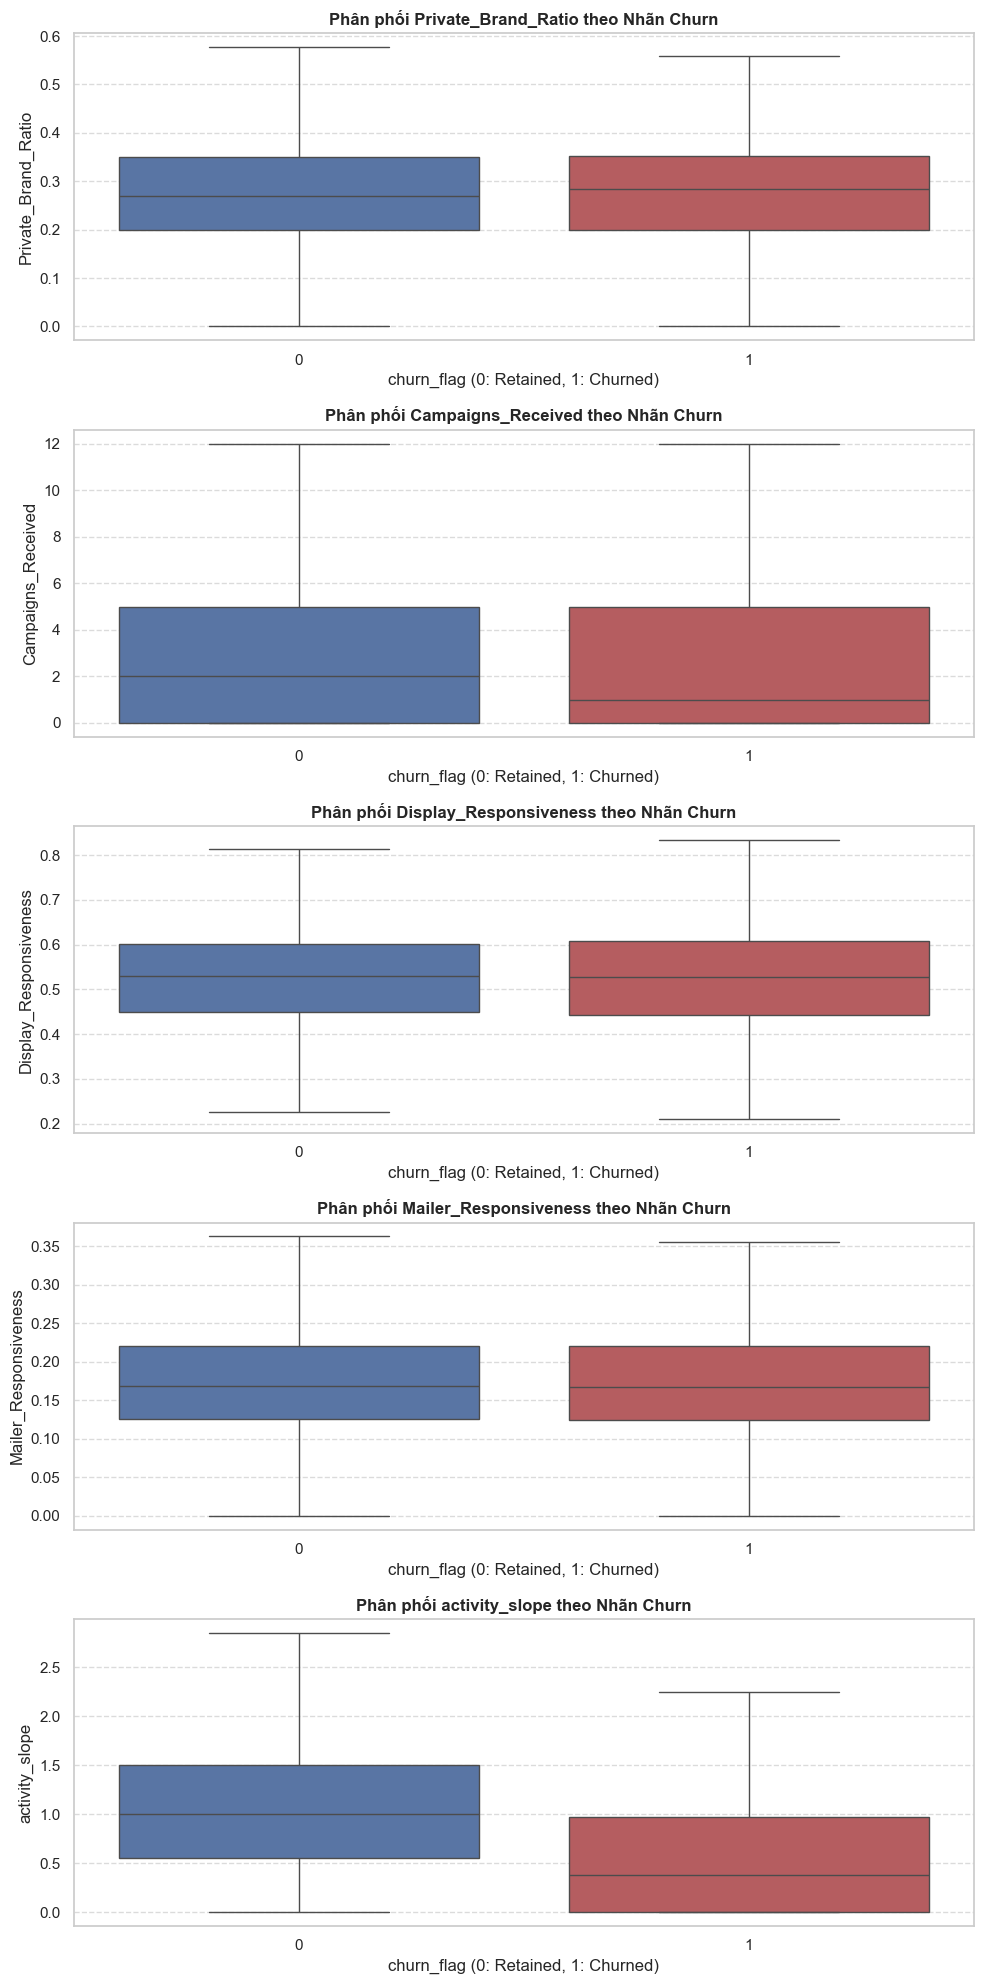

C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\346933993.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Admins\AppData\Local\Temp\ipykernel_28900\346933993.py:35: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


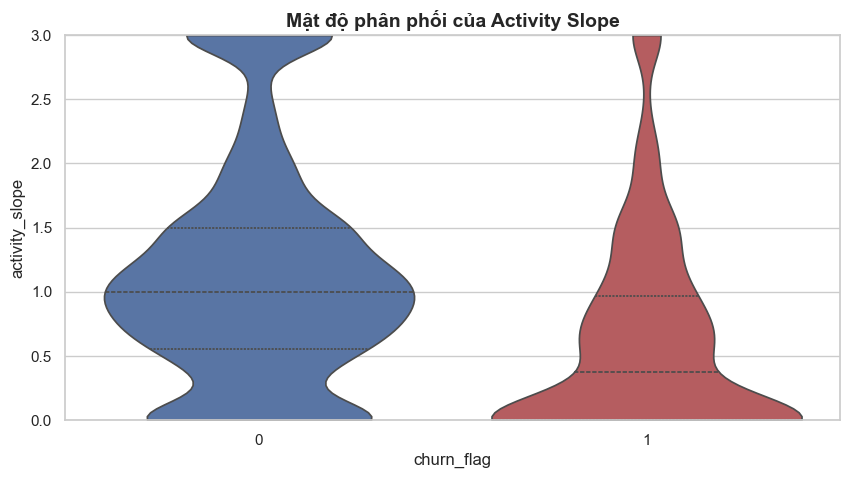

In [19]:
# ==============================================================================
# BƯỚC 4: VẼ BIỂU ĐỒ SO SÁNH CHURN VÀ NON-CHURN CHO CÁC FEATURES MỚI
# ==============================================================================

features_to_plot = ['Private_Brand_Ratio', 'Campaigns_Received', 'Display_Responsiveness', 'Mailer_Responsiveness', 'activity_slope']

# Dam bao churn_flag la chuoi de map dung palette
df_final['churn_flag'] = df_final['churn_flag'].astype(str)

# Thống kê mô tả
print("--- Giá trị Trung bình theo Nhãn Churn ---")
display(df_final.groupby('churn_flag')[features_to_plot].mean())

# Vẽ Boxplot
n_features = len(features_to_plot)
fig, axes = plt.subplots(n_features, 1, figsize=(10, 4 * n_features))
colors = {'0': '#4C72B0', '1': '#C44E52'}

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='churn_flag', y=col, data=df_final, ax=axes[i], showfliers=False, palette=colors)
    axes[i].set_title(f'Phân phối {col} theo Nhãn Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('churn_flag (0: Retained, 1: Churned)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Vẽ Violin plot riêng cho Activity Slope (Quan trọng)
plot_df = df_final[['churn_flag', 'activity_slope']].copy()
plot_df['activity_slope'] = pd.to_numeric(plot_df['activity_slope'], errors='coerce')
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['activity_slope'])
plot_df['activity_slope'] = plot_df['activity_slope'].clip(0, 3)

plt.figure(figsize=(10, 5))
sns.violinplot(
    x='churn_flag',
    y='activity_slope',
    data=plot_df,
    palette=colors,
    cut=0,
    inner='quartile',
    bw_adjust=0.8,
    scale='width'
  )
plt.title('Mật độ phân phối của Activity Slope', fontsize=14, fontweight='bold')
plt.ylim(0, 3)
plt.show()